In [1]:
import os

IN_COLAB = None

if IN_COLAB is None:
    try:
        import google.colab
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BANANA_DATASET = "/content/drive/MyDrive/content/banana_dataset"
    BANANA_SPLIT   = "/content/drive/MyDrive/content/banana_split"
else:
    _base          = os.path.dirname(os.path.abspath("__file__"))
    BANANA_DATASET = os.path.join(_base, "banana_dataset")
    BANANA_SPLIT   = os.path.join(_base, "banana_split")

print(f"Running {'in Colab' if IN_COLAB else 'locally'}")
print(f"BANANA_DATASET = {BANANA_DATASET}")
print(f"BANANA_SPLIT   = {BANANA_SPLIT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab
BANANA_DATASET = /content/drive/MyDrive/content/banana_dataset
BANANA_SPLIT   = /content/drive/MyDrive/content/banana_split


In [3]:
from PIL import Image
import os
from concurrent.futures import ThreadPoolExecutor

def _resize_one(args):
    path, size = args
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize(size, Image.LANCZOS)
        img.save(path)
    except Exception as e:
        print("Skipped:", os.path.basename(path), "-", e)

def resize_images(input_folder, size=(224, 224), workers=32):
    paths = [
        (os.path.join(input_folder, f), size)
        for f in os.listdir(input_folder)
        if not f.startswith(".")
    ]
    with ThreadPoolExecutor(max_workers=workers) as executor:
        list(executor.map(_resize_one, paths))

resize_images(os.path.join(BANANA_DATASET, "healthy"))
resize_images(os.path.join(BANANA_DATASET, "unhealthy"))


Skipped: (2).DS_Store - cannot identify image file '/content/drive/MyDrive/content/banana_dataset/healthy/(2).DS_Store'


In [4]:
import os

healthy_count = len([f for f in os.listdir(os.path.join(BANANA_DATASET, "healthy")) if not f.startswith(".")])
unhealthy_count = len([f for f in os.listdir(os.path.join(BANANA_DATASET, "unhealthy")) if not f.startswith(".")])

print("Healthy images:", healthy_count)
print("Unhealthy images:", unhealthy_count)
print("Total images:", healthy_count + unhealthy_count)


Healthy images: 5629
Unhealthy images: 5767
Total images: 11396


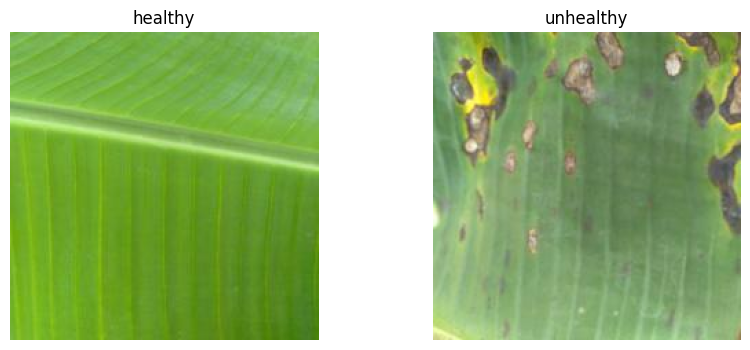

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

folders = [
    os.path.join(BANANA_DATASET, "healthy"),
    os.path.join(BANANA_DATASET, "unhealthy"),
]

plt.figure(figsize=(10, 4))

for i, folder in enumerate(folders):
    files = [f for f in os.listdir(folder) if not f.startswith(".")]
    sample = random.choice(files)
    img = Image.open(os.path.join(folder, sample))

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(folder))
    plt.axis("off")

plt.show()


In [9]:
import os
import shutil
import random

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def split_data(source, train_dir, test_dir, split_ratio=0.8):
    files = [f for f in os.listdir(source) if os.path.splitext(f)[1].lower() in IMAGE_EXTS]
    random.shuffle(files)

    split_idx = int(len(files) * split_ratio)
    train_files = files[:split_idx]
    test_files = files[split_idx:]

    for f in train_files:
        shutil.copy(os.path.join(source, f), os.path.join(train_dir, f))

    for f in test_files:
        shutil.copy(os.path.join(source, f), os.path.join(test_dir, f))


# Create folders
os.makedirs(os.path.join(BANANA_SPLIT, "train", "healthy"),   exist_ok=True)
os.makedirs(os.path.join(BANANA_SPLIT, "train", "unhealthy"), exist_ok=True)
os.makedirs(os.path.join(BANANA_SPLIT, "test",  "healthy"),   exist_ok=True)
os.makedirs(os.path.join(BANANA_SPLIT, "test",  "unhealthy"), exist_ok=True)

# Split data
split_data(
    os.path.join(BANANA_DATASET, "healthy"),
    os.path.join(BANANA_SPLIT, "train", "healthy"),
    os.path.join(BANANA_SPLIT, "test",  "healthy"),
)
split_data(
    os.path.join(BANANA_DATASET, "unhealthy"),
    os.path.join(BANANA_SPLIT, "train", "unhealthy"),
    os.path.join(BANANA_SPLIT, "test",  "unhealthy"),
)


In [11]:
import numpy as np
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def _load_one(args):
    path, label = args
    img = Image.open(path).convert("RGB").resize((64, 64))
    return np.array(img).flatten(), label

def load_images(folder, label, workers=16):
    paths = [(os.path.join(folder, f), label)
             for f in os.listdir(folder)
             if os.path.splitext(f)[1].lower() in IMAGE_EXTS]
    with ThreadPoolExecutor(max_workers=workers) as ex:
        results = list(tqdm(ex.map(_load_one, paths), total=len(paths),
                            desc=os.path.basename(folder), leave=False))
    return [r[0] for r in results], [r[1] for r in results]

def load_split(split_dir):
    X, y = [], []
    for label, cls in enumerate(["healthy", "unhealthy"]):
        imgs, labels = load_images(os.path.join(split_dir, cls), label)
        X.extend(imgs); y.extend(labels)
    return np.array(X) / 255.0, np.array(y)

print("Loading train...")
X_train, y_train = load_split(os.path.join(BANANA_SPLIT, "train"))
print("Loading test...")
X_test,  y_test  = load_split(os.path.join(BANANA_SPLIT, "test"))
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (10917, 12288), Test: (4082, 12288)


In [17]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import time

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=1),
    "Linear SVM":          LinearSVC(max_iter=2000),
    "Non-linear SVM":      SVC(kernel="rbf"),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1),
    "XGBoost":             XGBClassifier(n_estimators=100, eval_metric="logloss", random_state=42, n_jobs=1),
}

def train_eval(name, model):
    t0 = time.time()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall":    round(recall_score(y_test, preds), 4),
        "F1 Score":  round(f1_score(y_test, preds), 4),
        "Time (s)":  round(time.time() - t0, 1),
    }

results = Parallel(n_jobs=5, prefer="threads")(
    delayed(train_eval)(name, model)
    for name, model in tqdm(models.items(), desc="Training models")
)

df_results = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
df_results


Training models:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,Time (s)
0,XGBoost,0.9936,0.9937,0.9937,0.9937,291.8
1,Random Forest,0.9919,0.9885,0.9957,0.9921,153.6
2,Linear SVM,0.9772,0.9839,0.9711,0.9775,202.8
3,Logistic Regression,0.9674,0.9737,0.9620,0.9678,71.0
4,Non-linear SVM,0.9574,0.9731,0.9422,0.9574,761.7


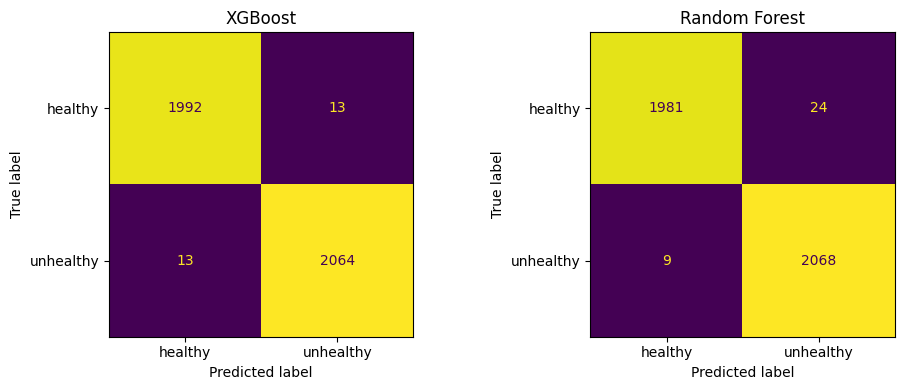

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D scatter of PC1 vs PC2
for split, X, y, ax in [("Train", X_train, y_train, axes[0]), ("Test", X_test, y_test, axes[1])]:
    for label, cls, color in [(0, "healthy", "green"), (1, "unhealthy", "red")]:
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], s=10, alpha=0.5, label=cls, color=color)
    ax.set_title(f"PCA — {split}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

plt.tight_layout()
plt.show()

# Explained variance curve
from sklearn.decomposition import PCA as _PCA
pca_full = _PCA().fit(X_train)
cumvar = pca_full.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar)
plt.axhline(0.90, color="r", linestyle="--", label="90% variance")
plt.axvline(150, color="g", linestyle="--", label="n_components=150")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

top2 = df_results["Model"].iloc[:2].tolist()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, top2):
    preds = models[name].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=["healthy", "unhealthy"],
        ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [16]:
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import time

pca = PCA(n_components=150, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)
print(f"PCA: {X_train.shape} → {X_train_pca.shape}  (variance retained: {pca.explained_variance_ratio_.sum():.2%})")

models_pca = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Linear SVM":          LinearSVC(max_iter=2000),
    "Non-linear SVM":      SVC(kernel="rbf"),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=100, eval_metric="logloss", random_state=42, n_jobs=-1),
}

def train_eval_pca(name, model):
    t0 = time.time()
    model.fit(X_train_pca, y_train)
    preds = model.predict(X_test_pca)
    return {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "Recall":    round(recall_score(y_test, preds), 4),
        "F1 Score":  round(f1_score(y_test, preds), 4),
        "Time (s)":  round(time.time() - t0, 1),
    }

print("Training with PCA features...")
results_pca = Parallel(n_jobs=5, prefer="threads")(
    delayed(train_eval_pca)(name, model) for name, model in tqdm(models_pca.items(), desc="Training (PCA)")
)

df_pca = pd.DataFrame(results_pca).sort_values("F1 Score", ascending=False).reset_index(drop=True)
df_pca


PCA: (10917, 12288) → (10917, 150)  (variance retained: 87.19%)
Training with PCA features...


Training (PCA):   0%|          | 0/5 [00:00<?, ?it/s]

,Model,Accuracy,Precision,Recall,F1 Score,Time (s)
0,XGBoost,0.9929,0.9937,0.9923,0.9930,4.4
1,Random Forest,0.9885,0.9833,0.9942,0.9887,2.3
2,Non-linear SVM,0.9623,0.9791,0.9461,0.9623,3.9
3,Linear SVM,0.8812,0.8976,0.8652,0.8811,0.5
4,Logistic Regression,0.8807,0.8947,0.8676,0.8810,2.7
